<a href="https://colab.research.google.com/github/Parthwadekar40/Parth40-MachineVision/blob/main/Prac1_MV_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please select and upload your low-light surveillance image from your PC:


Saving 1c5d48bf8a55b71871d937d5e9e51ec8fec44ab3_2_690x318.jpeg to 1c5d48bf8a55b71871d937d5e9e51ec8fec44ab3_2_690x318.jpeg

Processing '1c5d48bf8a55b71871d937d5e9e51ec8fec44ab3_2_690x318.jpeg' through the surveillance enhancement pipeline...


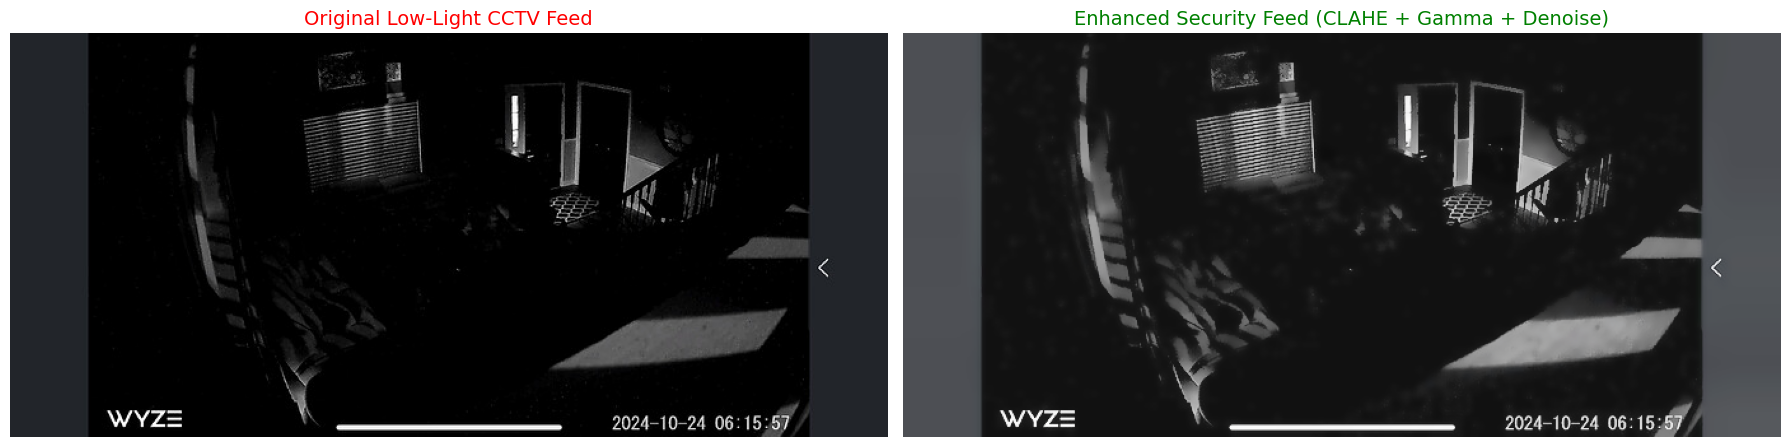

✓ Done! Enhanced image saved as 'enhanced_surveillance.jpg' in your local files workspace.


In [1]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def enhance_nighttime_image(img_path_or_bytes):
    # 1. Load the Image (Support both file path and raw bytes from Google Colab)
    if isinstance(img_path_or_bytes, bytes):
        nparr = np.frombuffer(img_path_or_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(img_path_or_bytes)

    if img is None:
        raise ValueError("Could not read the uploaded image. Ensure it is a valid JPG/PNG.")

    # Convert BGR to RGB for matplotlib plotting
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Convert to LAB color space to process Luminance (L) channel separately
    # This ensures colors don't shift during contrast and brightness adjustment
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # 3. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # clipLimit prevents excessive noise amplification in completely black zones
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl_enhanced = clahe.apply(l_channel)

    # Recombine channels and convert back to BGR
    merged_lab = cv2.merge((cl_enhanced, a_channel, b_channel))
    bgr_enhanced = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2BGR)

    # 4. Brightness Enhancement (Non-linear Gamma Correction)
    # gamma > 1.0 brightens shadows cleanly without blowing out white spots
    gamma = 1.4
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(256)]).astype("uint8")
    brightened = cv2.LUT(bgr_enhanced, table)

    # 5. Noise Removal & Edge Preservation (Bilateral Filtering)
    # Unlike standard blur, this preserves critical object boundaries (suspects, plates)
    denoised = cv2.bilateralFilter(brightened, d=9, sigmaColor=75, sigmaSpace=75)

    # Convert results to RGB for display
    enhanced_rgb = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

    return img_rgb, enhanced_rgb

# --- Google Colab Execution Block ---
print("Please select and upload your low-light surveillance image from your PC:")
uploaded = files.upload()

if uploaded:
    # Get the first uploaded file's data
    file_name = list(uploaded.keys())[0]
    image_bytes = uploaded[file_name]

    print(f"\nProcessing '{file_name}' through the surveillance enhancement pipeline...")

    try:
        original, enhanced = enhance_nighttime_image(image_bytes)

        # Plot the comparison
        plt.figure(figsize=(18, 10))

        plt.subplot(1, 2, 1)
        plt.imshow(original)
        plt.title("Original Low-Light CCTV Feed", fontsize=14, color='red')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(enhanced)
        plt.title("Enhanced Security Feed (CLAHE + Gamma + Denoise)", fontsize=14, color='green')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # Save output to your Colab directory
        cv2.imwrite("enhanced_surveillance.jpg", cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))
        print("✓ Done! Enhanced image saved as 'enhanced_surveillance.jpg' in your local files workspace.")

    except Exception as e:
        print(f"Error during processing: {e}")
else:
    print("No file was uploaded.")